In [1]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
y_train.shape

(60000,)

In [5]:
X_test.shape

(10000, 28, 28)

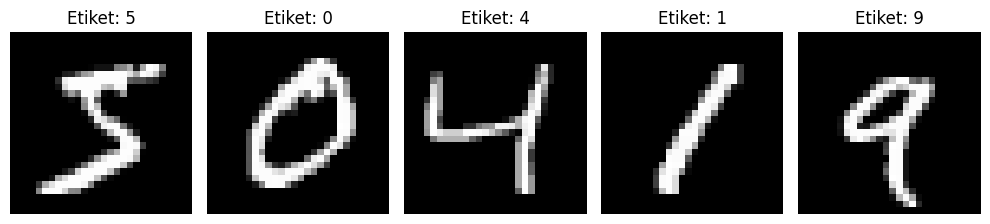

In [6]:
plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Etiket: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
X_train = X_train.astype('float32') / 255.0

X_test = X_test.astype('float32') / 255.0

In [8]:
X_train = np.expand_dims(X_train, axis=-1)

X_test = np.expand_dims(X_test, axis=-1)

In [9]:
X_train.shape

(60000, 28, 28, 1)

In [10]:
X_train.max()

np.float32(1.0)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [12]:
baseline_model = models.Sequential(
    [
        layers.Flatten(input_shape=(28, 28, 1)),

        layers.Dense(128, activation="relu"),

        layers.Dense(64, activation="relu"),

        layers.Dense(10, activation="softmax"),
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [15]:
history_baseline = baseline_model.fit(
    X_train, y_train, epochs=5, batch_size=64, validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9154 - loss: 0.2967 - val_accuracy: 0.9598 - val_loss: 0.1372
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9637 - loss: 0.1205 - val_accuracy: 0.9730 - val_loss: 0.0918
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9754 - loss: 0.0820 - val_accuracy: 0.9758 - val_loss: 0.0791
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9806 - loss: 0.0625 - val_accuracy: 0.9775 - val_loss: 0.0794
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9855 - loss: 0.0475 - val_accuracy: 0.9783 - val_loss: 0.0787


In [16]:
test_loss, test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)

In [18]:
test_acc * 100

97.39999771118164

In [19]:
cnn_model = models.Sequential(
    [

     layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),

     layers.MaxPooling2D((2, 2)),

     layers.Conv2D(64, (3, 3), activation="relu"),

     layers.MaxPooling2D((2, 2)),

     layers.Conv2D(64, (3, 3), activation="relu"),

     layers.Flatten(),

     layers.Dense(64, activation="relu"),

     layers.Dense(10, activation="softmax"),
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [22]:
history_cnn = cnn_model.fit(
    X_train, y_train, epochs=5, batch_size=64, validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9439 - loss: 0.1827 - val_accuracy: 0.9860 - val_loss: 0.0498
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 56ms/step - accuracy: 0.9845 - loss: 0.0502 - val_accuracy: 0.9847 - val_loss: 0.0524
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9893 - loss: 0.0348 - val_accuracy: 0.9872 - val_loss: 0.0447
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - accuracy: 0.9909 - loss: 0.0273 - val_accuracy: 0.9885 - val_loss: 0.0433
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9935 - loss: 0.0208 - val_accuracy: 0.9903 - val_loss: 0.0370


In [23]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)

In [24]:
cnn_test_acc * 100

99.09999966621399

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

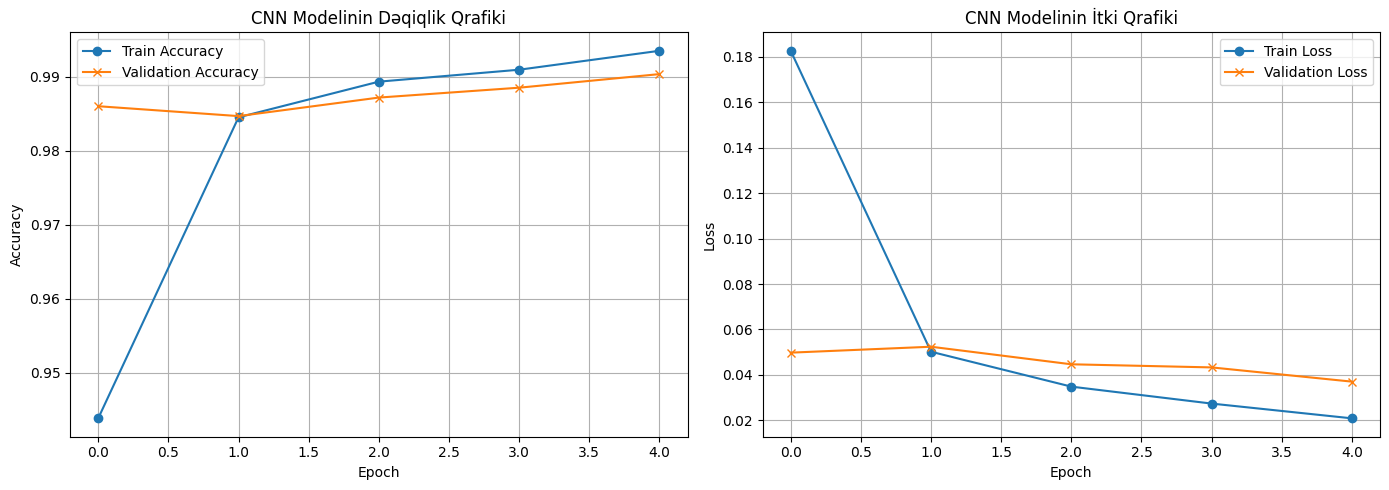

In [26]:
plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(history_cnn.history["accuracy"], label="Train Accuracy", marker="o")
plt.plot(
    history_cnn.history["val_accuracy"], label="Validation Accuracy", marker="x"
)
plt.title("CNN Modelinin Dəqiqlik Qrafiki")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history_cnn.history["loss"], label="Train Loss", marker="o")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss", marker="x")
plt.title("CNN Modelinin İtki Qrafiki")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:
y_pred_probabilities = cnn_model.predict(X_test)

y_pred = np.argmax(y_pred_probabilities, axis=1)

cm = confusion_matrix(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


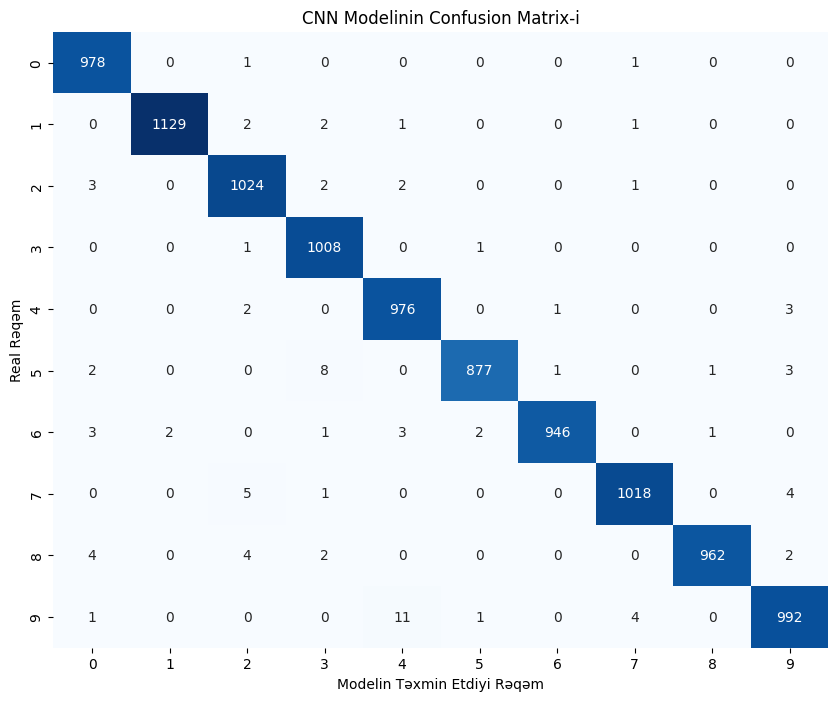

In [28]:
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("CNN Modelinin Confusion Matrix-i")
plt.xlabel("Modelin Təxmin Etdiyi Rəqəm")
plt.ylabel("Real Rəqəm")

plt.show()

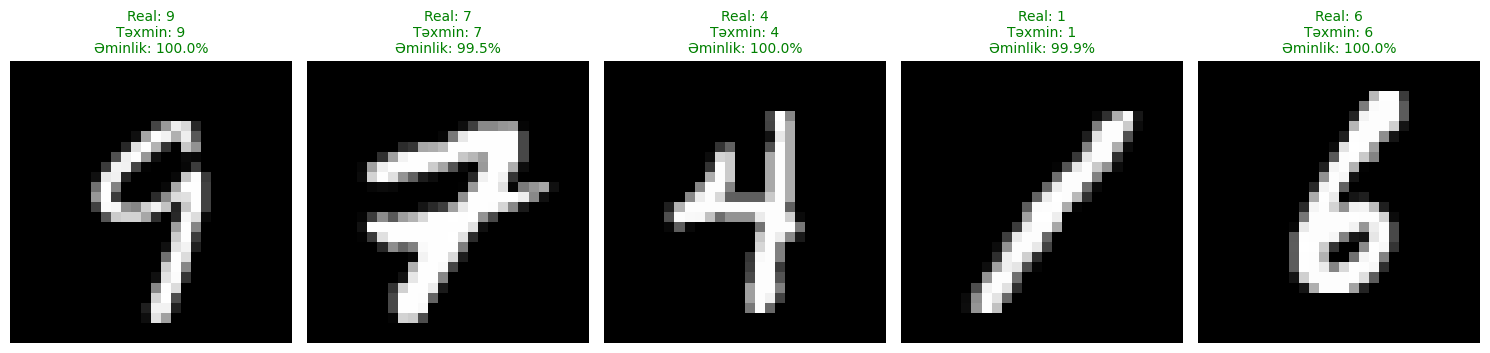

In [29]:
random_indices = np.random.choice(len(X_test), size=5, replace=False)

plt.figure(figsize=(15, 5))

for i, index in enumerate(random_indices):

    img = X_test[index]
    actual_label = y_test[index]

    img_for_pred = np.expand_dims(img, axis=0)

    predictions = cnn_model.predict(img_for_pred, verbose=0)
    predicted_label = np.argmax(predictions)
    confidence = (
        np.max(predictions) * 100
    )

    plt.subplot(1, 5, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")

    title_color = "green" if predicted_label == actual_label else "red"

    plt.title(
        f"Real: {actual_label}\nTəxmin: {predicted_label}\nƏminlik: {confidence:.1f}%",
        color=title_color,
        fontsize=10,
    )
    plt.axis("off")

plt.tight_layout()
plt.show()